# Statistiques de exdark

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lrivals/EmbeddedComputervision/blob/main/notebooks/exdark/exdark_stats.ipynb)

Présentation et analyse statistique du jeu, lues du point de vue de Tiny-YOLO et de la
cible embarquée (entrée 416, grilles 13×13 et 26×26, 256 emplacements de `yolo_post`,
INT8). Tâches : [T11.3](../../docs/tasks/M11-jeux-de-donnees.md), [T16.17](../../docs/tasks/M16-presentation-jeux.md), [T16.4](../../docs/tasks/M16-presentation-jeux.md) ; jalon : [M16](../../docs/tasks/M16-presentation-jeux.md) ;
synthèse : [stats-jeux.md](../../docs/tasks/stats-jeux.md). Autres notebooks du jeu :
[tiny-yolov2-voc_infer](tiny-yolov2-voc_infer.ipynb), [tiny-yolov3-coco_infer](tiny-yolov3-coco_infer.ipynb), [tiny-yolov3-exdark_infer](tiny-yolov3-exdark_infer.ipynb), [tiny-yolov3-exdark_train](tiny-yolov3-exdark_train.ipynb), [tiny-yolov3-exdark_sweep](tiny-yolov3-exdark_sweep.ipynb).

Palier : annotations **M (en-têtes d'image lus)** (split entier), pixels **M** (`SAMPLE = 200`
images par partie). Prérequis : données `data/exdark/imageclasslist.txt` — tools/get_datasets.sh exdark (inscription : source affichée). Ni poids ni GPU.

Question propre : Luminosité par type d'éclairage, et écart aux images de calibration VOC. (renvoi : T11.3).

| | |
|---|---|
| source | https://github.com/cs-chan/Exclusively-Dark-Image-Dataset |
| version | 2019, découpage officiel de imageclasslist.txt |
| licence | BSD 3-Clause (dépôt), recherche |
| capteur | photos en faible luminosité, 10 types d'éclairage, couleur |
| résolution typique | variable |
| officiel `train` | 3000 images, — objets |
| officiel `val` | 1800 images, — objets |
| officiel `test` | 2563 images, — objets |
| chargeur | type d'éclairage (3e colonne de imageclasslist.txt) lu par data_stats, pas par `load_exdark` |

Aucun calcul ici : `tools/data_stats.py` calcule (`stats.json`, `stats.md`, galerie),
`tools/figures/donnees.py` trace ; chaque étape affiche la commande. Sorties dans
`build/notebooks/exdark/stats/`, jamais dans `results/`. Notebook généré par `python -m tools.notebooks`
(`make notebooks`) : modifier `tools/notebooks/gabarits.py`, pas ce fichier.

## Paramètres

In [1]:
DATASET   = 'exdark'  # clé de DATASETS
SPLITS    = None  # liste de splits ; None : splits train puis test du jeu
SIZE      = None  # S ou 'LxH' ; None : entrée de la cfg du jeu (416 sinon)
RESIZE    = 'letterbox'  # letterbox | stretch (grandeurs vues par le réseau)
SAMPLE    = 200  # images lues pour les pixels, par partie ; 0 : aucune
GALLERY   = 8  # images de la galerie par split
SEED      = 0  # tirage des images (pixels, galerie, nuages)
NET       = 'build/m11/cfg/tiny-yolov3-exdark.cfg'  # cfg dont les ancres et grilles servent aux collisions
DEVICE    = 'cpu'  # noyau CPU : rien ne tourne sur GPU
DATA_ROOT = None  # racine du jeu ; None : data/<jeu> (Colab : dossier Drive)
DRIVE_DIR = '/content/drive/MyDrive/EmbeddedCV'  # Colab : archives data/<jeu>.tar ; None : pas de Drive
OUT       = 'build/notebooks/exdark/stats'  # sorties du notebook
REPO_URL  = 'https://github.com/lrivals/EmbeddedComputervision.git'  # Colab : dépôt cloné
REV       = 'main'  # Colab : révision

## Environnement

Local : rien n'est installé ni téléchargé, la cellule vérifie les prérequis et
s'arrête avec la commande à lancer. Colab : clone du dépôt, installation, CuPy si
`DEVICE = "gpu"`, poids, puis données par `colab.prepare_data` (archive
`<DRIVE_DIR>/data/<jeu>.tar` ou téléchargement direct ; ExDark et FLIR : archive
seulement, faite sur le PC par `tools/get_datasets.sh pack <jeu>`).

In [2]:
import os
import subprocess
import sys
from pathlib import Path

COLAB = "google.colab" in sys.modules


def repo_root():
    for d in (Path.cwd(), *Path.cwd().parents):
        if (d / "tools" / "notebooks" / "commandes.py").exists():
            return d
    return None


ROOT = repo_root()
if COLAB:
    if ROOT is None:
        ROOT = Path("/content/EmbeddedComputervision")
        if not ROOT.exists():
            subprocess.run(["git", "clone", REPO_URL, str(ROOT)], check=True)
    # Clone d'une session précédente : remis à REV (notebook et code du même commit).
    subprocess.run(["git", "-C", str(ROOT), "fetch", "-q", "origin", REV], check=True)
    subprocess.run(["git", "-C", str(ROOT), "checkout", "-q", "FETCH_HEAD"], check=True)
    for m in [m for m in sys.modules if m.split(".")[0] in ("tools", "yolo")]:
        del sys.modules[m]  # modules importés avant la mise à jour
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-e",
                    f"{ROOT}/python[data,plots]"], check=True)
    if DEVICE == "gpu":
        # Runtime CPU : pas de pilote, CuPy dirait « cudaErrorInsufficientDriver ».
        try:
            smi = subprocess.run(["nvidia-smi"], capture_output=True, text=True)
        except FileNotFoundError:
            smi = None
        if smi is None or smi.returncode != 0:
            raise RuntimeError("runtime Colab sans GPU : créer un nouveau serveur Colab "
                               "de type GPU (T4, L4 ou A100), ou DEVICE = 'cpu'")
        cuda = smi.stdout.split("CUDA Version:")[-1].split()[0]  # version du pilote
        cupy_pkg = "cupy-cuda13x" if int(cuda.split(".")[0]) >= 13 else "cupy-cuda12x"
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", cupy_pkg],
                       check=True)
elif ROOT is None:
    raise RuntimeError("racine du dépôt introuvable : ouvrir le notebook depuis notebooks/")
os.chdir(ROOT)
for p in (ROOT, ROOT / "python"):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

from tools.notebooks import commandes as C
from tools.notebooks import env

TRACE = env.trace(DEVICE)
env.check_device(DEVICE)
env.prepare(DATASET, (), None, DATA_ROOT, COLAB, hint='',
            drive_dir=DRIVE_DIR)
if str(NET).endswith(".cfg") and not env.restore_cfg(NET):
    print(f"cfg {NET} absente (tools/m11.sh {DATASET}-prep) : ancres et grilles de "
          "tiny-yolov3-coco pour les collisions")
    NET = "tiny-yolov3-coco"
Path(OUT).mkdir(parents=True, exist_ok=True)

dépôt /home/leonard/Documents/Perso/EmbeddedComputervision @ 214f269 (modifié) ; Python 3.12.3 ; NumPy 2.4.2 ; backend cpu
données exdark : data/exdark/imageclasslist.txt ; poids : —


## Calcul (T16.0)

`tools/data_stats.py` lit les annotations de chaque split (en entier), lit les pixels
de `SAMPLE` images par partie (tirées avec `SEED`), dessine la galerie et trace les
figures. Les grandeurs « vues par le réseau » sont calculées après `RESIZE` à `SIZE`.

In [3]:
import json

from IPython.display import Image as Img, Markdown, display

from tools import data_stats as DS
from tools.notebooks.matrice import SPLIT_IMAGES, palier_stats
from yolo.models.tiny_yolo import load_cfg

if SIZE is None:
    _, h, w = load_cfg(NET)["input"]
    SIZE = h if h == w else f"{w}x{h}"
ann, px = palier_stats(DATASET, SAMPLE)
print(f"palier : annotations {ann}, pixels {px} ({SAMPLE} images par partie) ; "
      f"entrée {SIZE} ({RESIZE}) ; cfg {NET}")
C.run(C.cmd_data_stats(DATASET, OUT, SPLITS, SIZE, RESIZE, NET, SAMPLE, GALLERY, SEED,
                       data_root=DATA_ROOT))
STATS = json.loads(Path(OUT, "stats.json").read_text())
FIG = Path(OUT, "figures")


def show(name):
    png = FIG / f"{name}.png"
    if png.exists():
        display(Img(filename=str(png)))


def table(fn):
    text = fn(STATS)
    if text:
        display(Markdown(text))

palier : annotations M, pixels M (200 images par partie) ; entrée 416 (letterbox) ; cfg build/m11/cfg/tiny-yolov3-exdark.cfg
$ python tools/data_stats.py --dataset exdark --size 416 --resize letterbox --net build/m11/cfg/tiny-yolov3-exdark.cfg --sample 200 --gallery 8 --seed 0 --figures --out build/notebooks/exdark/stats


chargement exdark train…


chargement exdark test…


analyses train (3000 images)…


analyses test (2563 images)…


...

→ build/notebooks/exdark/stats/figures/eclairage.png


→ build/notebooks/exdark/stats/figures/ancres.png


→ build/notebooks/exdark/stats/figures/ancres_k.png


→ build/notebooks/exdark/stats/figures/ecart.png


  (16 s)


## Présentation et galerie (T16.4)

Classes du jeu et leur correspondance VOC et COCO (`MAPPINGS`), puis `GALLERY` images
par split, une image par classe ; vérités terrain dessinées par `tools/detect.py:draw`.
À `SEED` fixé, la galerie ne change pas.

| classe | VOC | COCO |
|---|---|---|
| Bicycle | bicycle | bicycle |
| Boat | boat | boat |
| Bottle | bottle | bottle |
| Bus | bus | bus |
| Car | car | car |
| Cat | cat | cat |
| Chair | chair | chair |
| Cup | — | cup |
| Dog | dog | dog |
| Motorbike | motorbike | motorbike |
| People | person | person |
| Table | diningtable | diningtable |

galerie : train


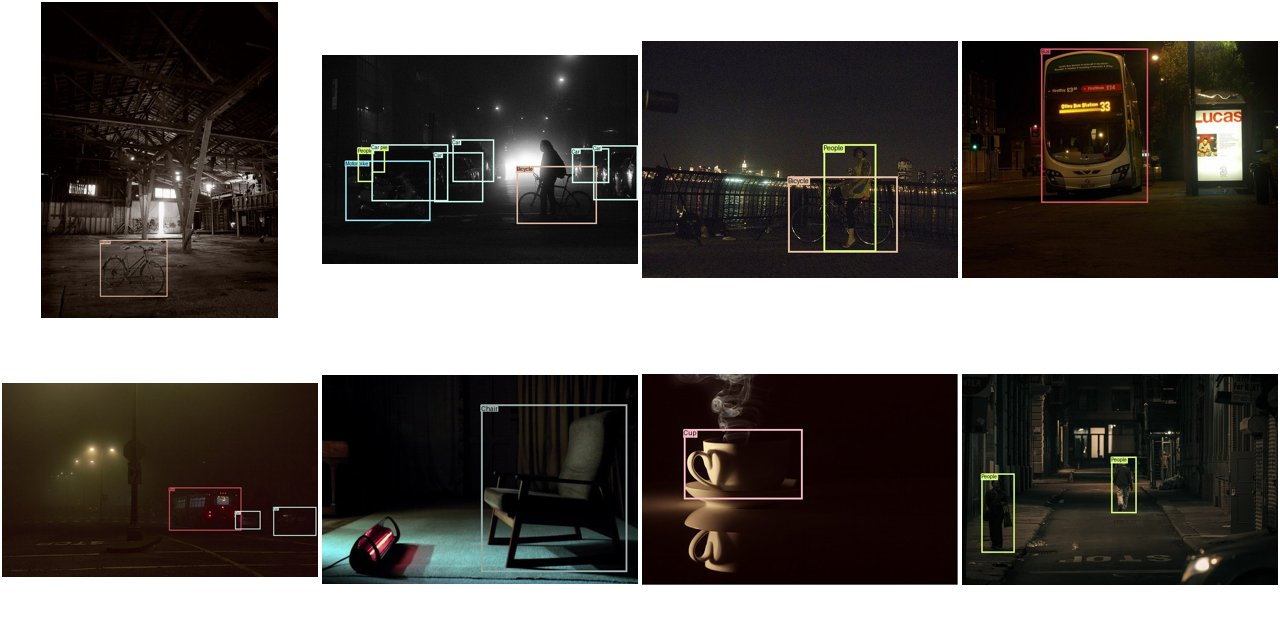

galerie : test


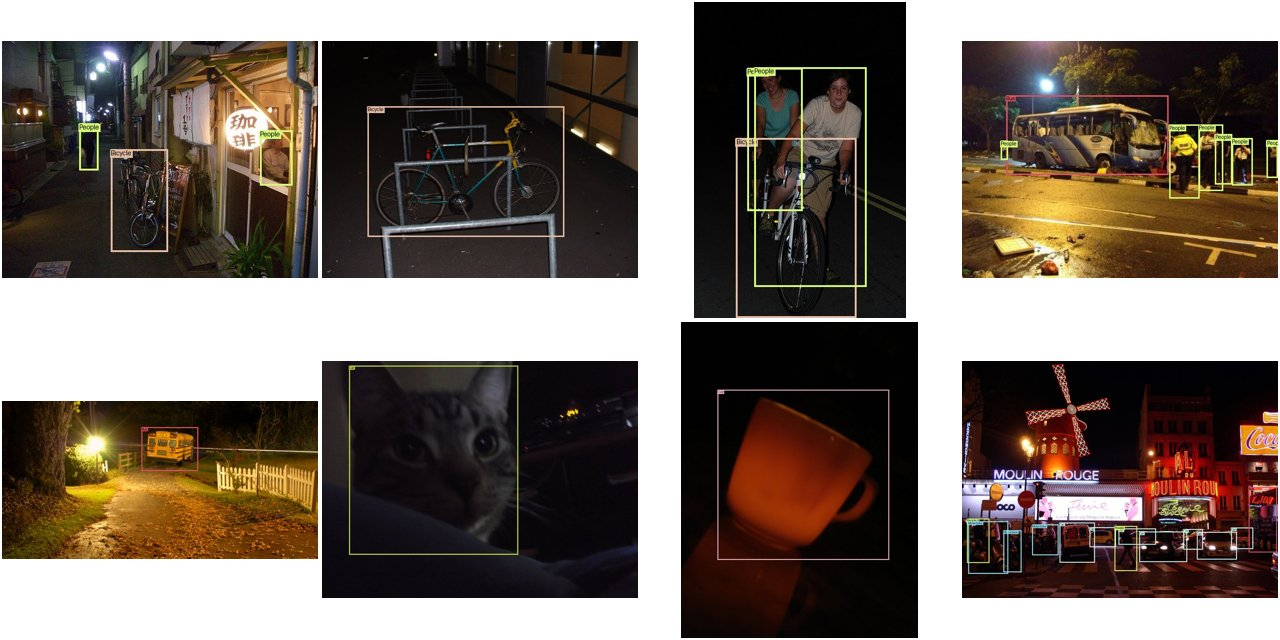

galerie : classes


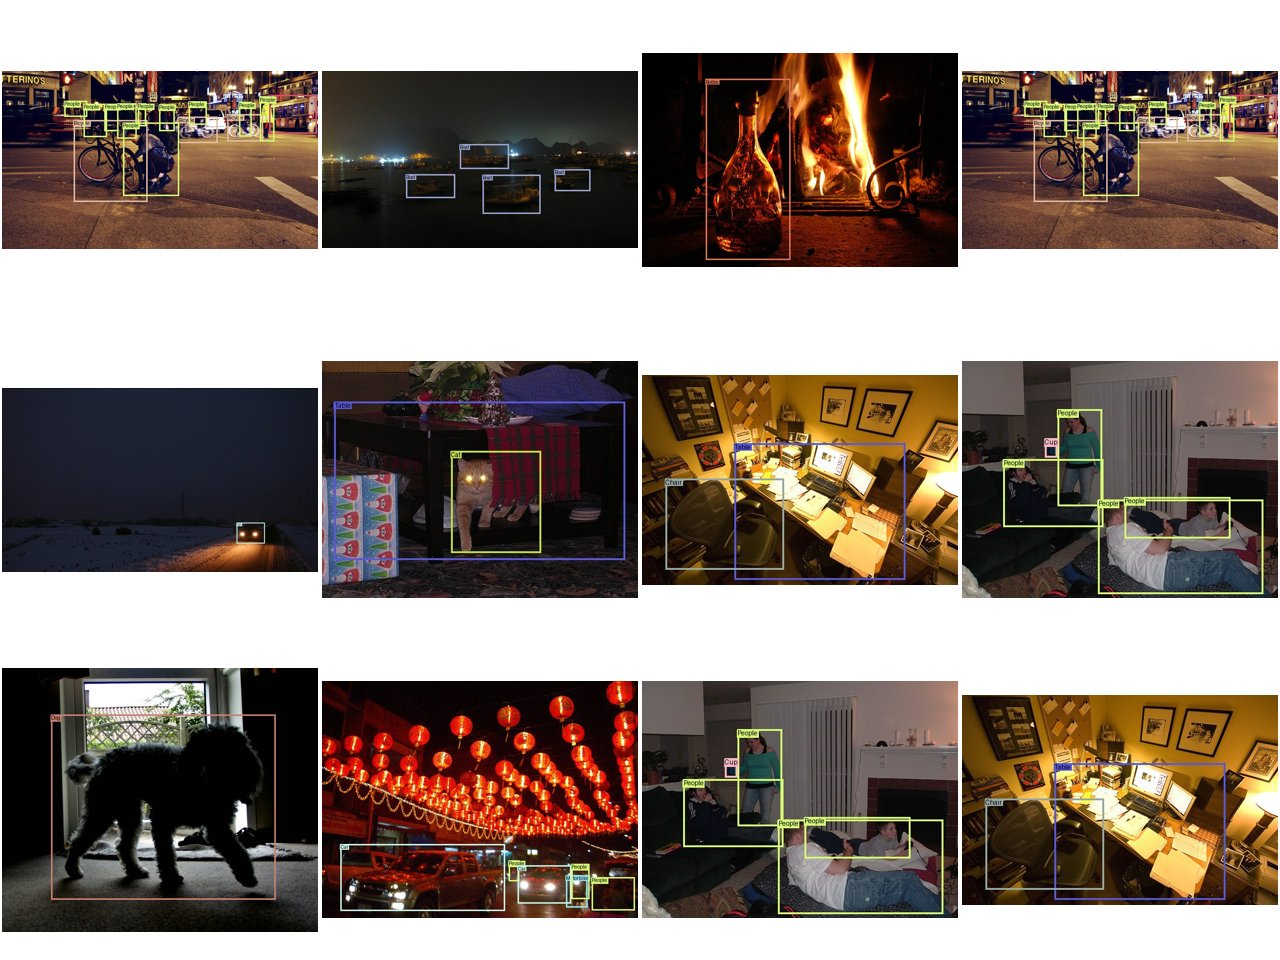

In [4]:
from yolo.data import datasets as D

rows = ["| classe | VOC | COCO |", "|---|---|---|"]
for c in D.DATASETS[DATASET].classes:
    m = [c if DATASET == f else D.MAPPINGS.get((DATASET, f), {}).get(c, "—")
         for f in ("voc", "coco")]
    rows.append(f"| {c} | {m[0]} | {m[1]} |")
display(Markdown("\n".join(rows)))
for g, sheet in STATS.get("galerie", {}).get("planches", {}).items():
    if g != "suspectes":
        print(f"galerie : {g}")
        display(Img(filename=str(Path(OUT, sheet))))

## Comptes et classes (T16.5)

Comptes par split (annotations, split entier), face aux effectifs officiels de la
fiche ; objets par classe et co-occurrence.

| partie | images | objets | difficult | images vides | objets/image (méd. / max) | petits < 32² à 416×416 | plus petits qu'une cellule | cibles perdues | images > 256 / > 1 024 |
|---|---|---|---|---|---|---|---|---|---|
| train | 3 000 | 10 381 | 0 | 1 | 2 / 33 | 17,8 % | 13x13 10,4 % · 26x26 0,6 % | 0,56 % | 0 / 0 |
| test | 2 563 | 7 117 | 0 | 0 | 2 / 30 | 18,5 % | 13x13 11,8 % · 26x26 1,7 % | 1,00 % | 0 / 0 |
| ensemble | 5 563 | 17 498 | 0 | 1 | 2 / 33 | 18,1 % | 13x13 11,0 % · 26x26 1,0 % | 0,74 % | 0 / 0 |

train : 3000 images, 10381 objets ; officiel 3000 / — : ok
test : 2563 images, 7117 objets ; officiel 2563 / — : ok


| classe | train : objets (images) | test : objets (images) | côté médian (px, letterbox) | petits |
|---|---|---|---|---|
| Bicycle | 463 (308) | 418 (272) | 92 | 9 % |
| Boat | 530 (255) | 515 (287) | 70 | 16 % |
| Bottle | 654 (322) | 433 (172) | 60 | 19 % |
| Bus | 333 (266) | 164 (137) | 156 | 4 % |
| Car | 1 238 (547) | 919 (412) | 51 | 26 % |
| Cat | 311 (261) | 425 (346) | 120 | 9 % |
| Chair | 1 138 (535) | 609 (383) | 86 | 6 % |
| Cup | 864 (400) | 356 (194) | 49 | 30 % |
| Dog | 335 (273) | 490 (427) | 127 | 5 % |
| Motorbike | 490 (284) | 242 (128) | 80 | 13 % |
| People | 3 271 (1 183) | 2 235 (841) | 53 | 26 % |
| Table | 754 (473) | 311 (224) | 102 | 4 % |

Rapport classe la plus / la moins fréquente : 11.

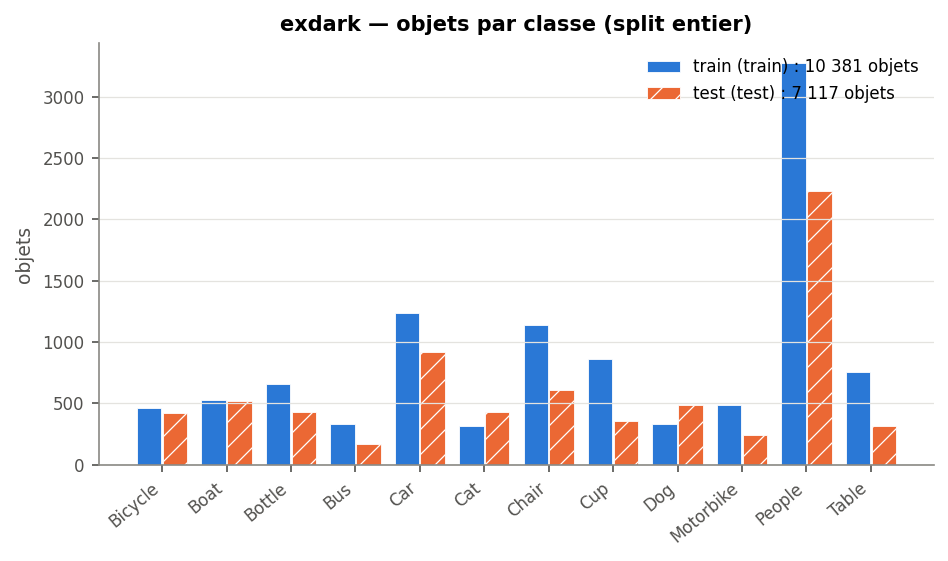

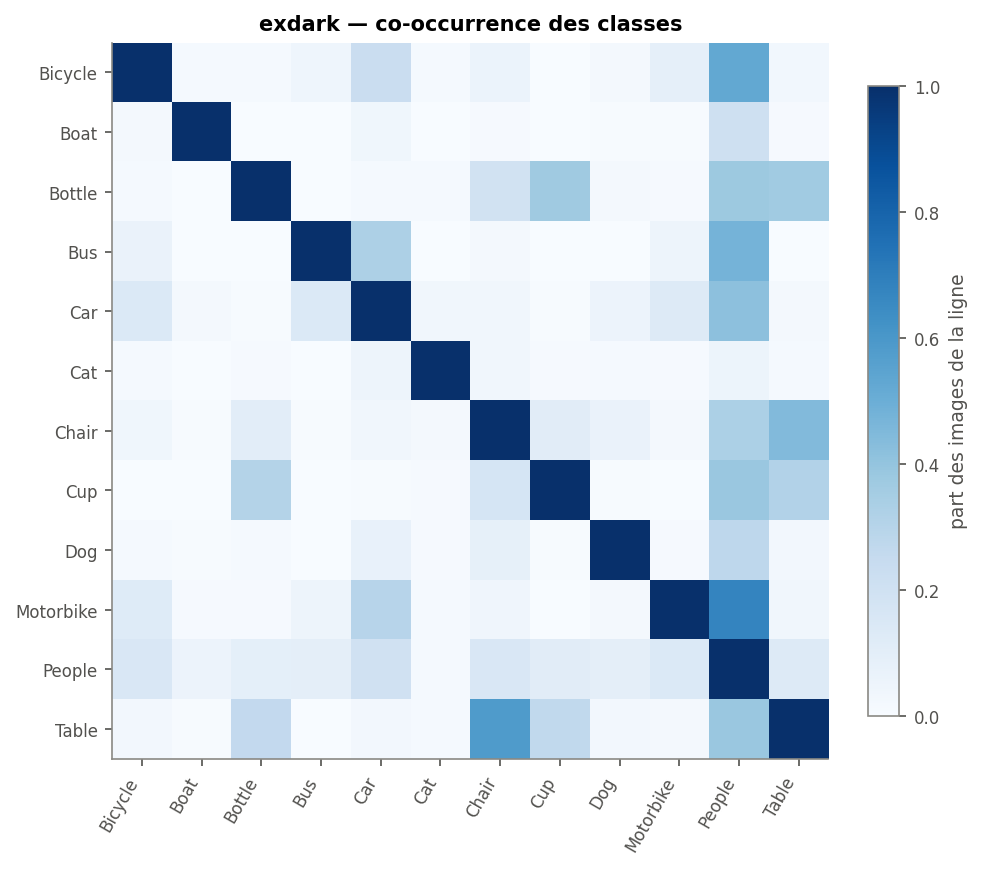

In [5]:
table(DS.md_synthese)
chk = DS.check_official(STATS)
for sp, i, o, (a, b), ok in chk:
    print(f"{sp} : {i} images, {o} objets ; officiel {a or '—'} / {b or '—'} : "
          f"{'ok' if ok else 'écart (voir les notes de la fiche)'}")
table(DS.md_classes)
show("classes")
show("cooccurrence")

## Géométrie des boîtes (T16.6)

Tailles en pixels d'origine et d'entrée (letterbox et stretch à `SIZE`), catégories
COCO avant et après redimensionnement, part des objets plus petits qu'une cellule de
chaque tête, centres des boîtes.

| repère | petits | moyens | grands | côté médian (px) | plus petits qu'une cellule | hauteur < 8 px |
|---|---|---|---|---|---|---|
| image d'origine | 5,6 % | 35,1 % | 59,3 % | 120 | — | — |
| letterbox 416×416 | 18,1 % | 46,6 % | 35,2 % | 69 | 13x13 11,0 % · 26x26 1,0 % | 0,0 % |
| stretch 416×416 | 12,5 % | 43,5 % | 43,9 % | 84 | 13x13 5,6 % · 26x26 0,2 % | 0,0 % |

17 498 objets non-difficult ; pas des têtes : 13x13 → 32 px, 26x26 → 16 px.

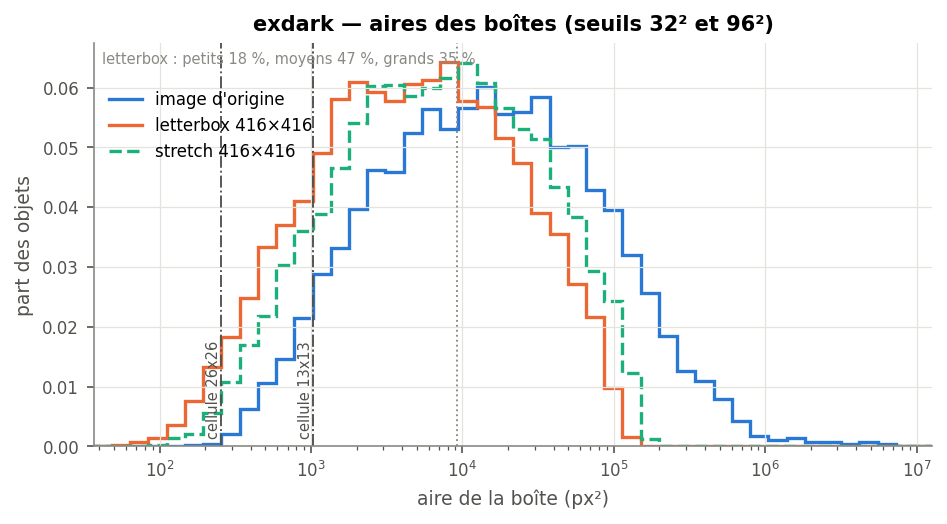

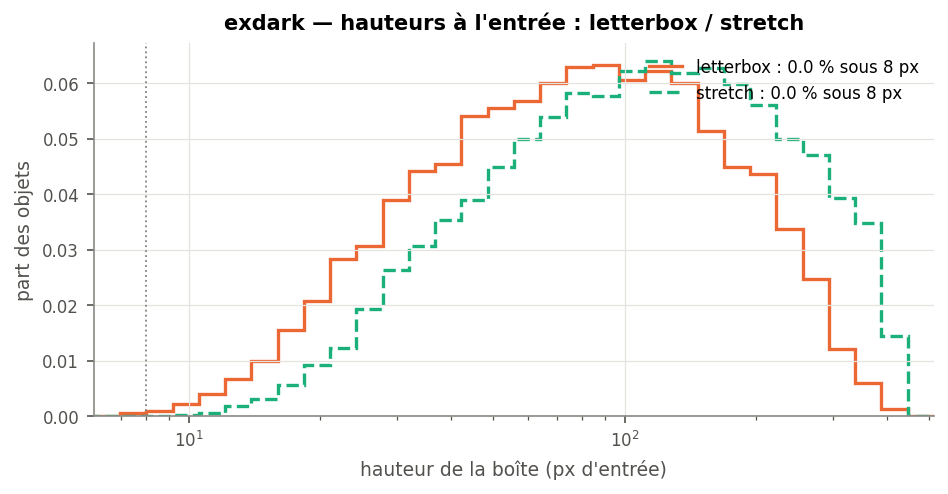

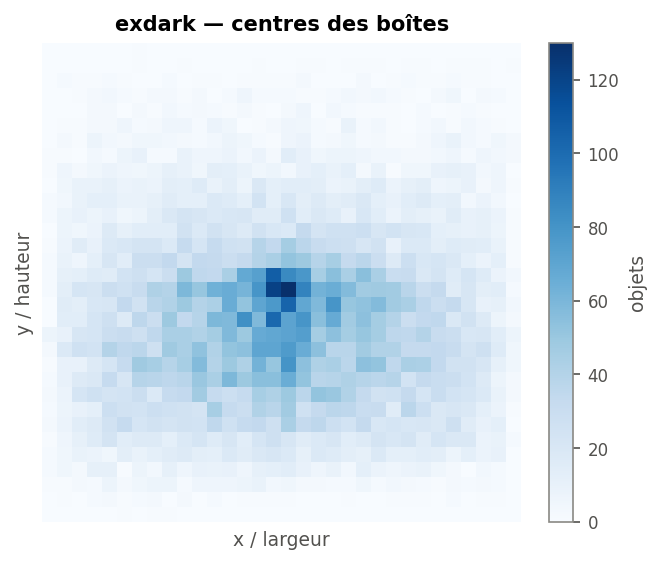

In [6]:
table(DS.md_geometrie)
show("tailles")
show("letterbox_stretch")
show("centres")

## Densité et collisions (T16.7)

Objets par image face aux 256 emplacements de `yolo_post` ; cibles perdues quand deux
objets tombent sur la même cellule et la même ancre (`build_targets`, ancres de `NET`).

| partie | objets/image moy. | méd. | max | > 256 / > 1 024 | cibles perdues | par tête (perdues / objets) | images touchées |
|---|---|---|---|---|---|---|---|
| train | 3,5 | 2 | 33 | 0 / 0 | 58 / 10 381 (0,56 %) | 13x13 : 4 / 2 808 · 26x26 : 54 / 7 573 | 48 |
| test | 2,8 | 2 | 30 | 0 / 0 | 71 / 7 117 (1,00 %) | 13x13 : 3 / 2 269 · 26x26 : 68 / 4 848 | 60 |
| ensemble | 3,1 | 2 | 33 | 0 / 0 | 129 / 17 498 (0,74 %) | 13x13 : 7 / 5 077 · 26x26 : 122 / 12 421 | 108 |

Ancres de `build/m11/cfg/tiny-yolov3-exdark.cfg` ; objets non-difficult, comme à l'entraînement.

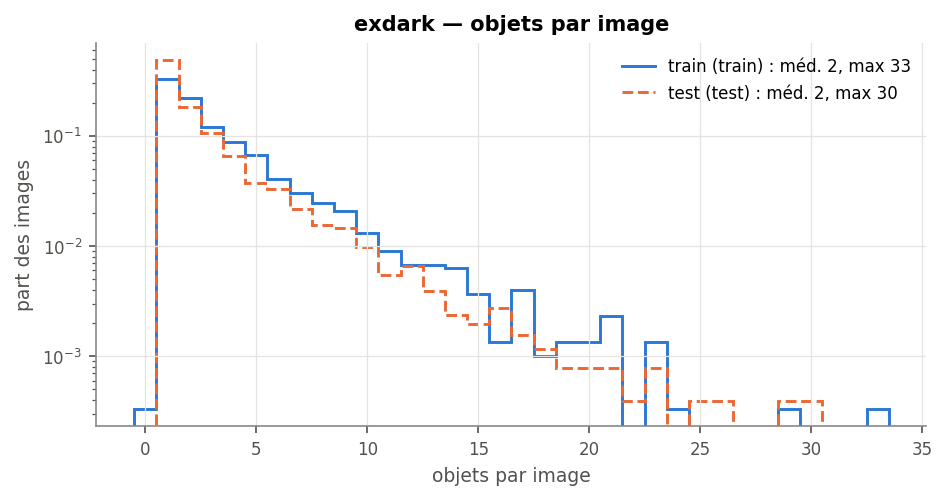

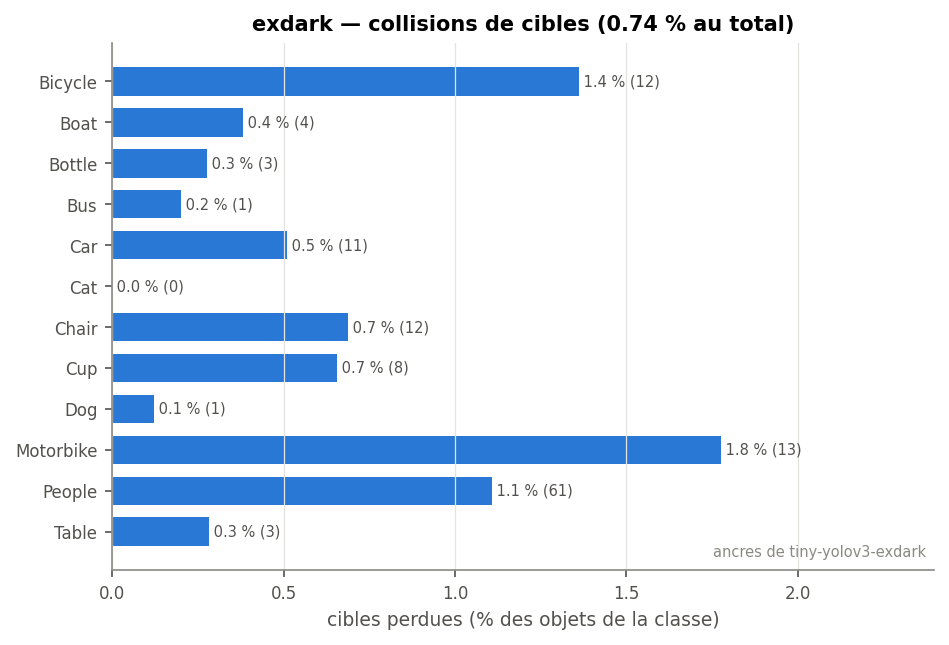

In [7]:
table(DS.md_densite)
show("densite")
show("collisions")

## Images (T16.8)

Résolutions sur le split entier (annotations) ; canaux, intensités et luminance sur
`SAMPLE` images par partie, face à VOC2007 test (échelles INT8 de M4).

| partie | résolutions (3 premières) | distinctes | pixels sur | canaux | moyenne par canal | écart type par canal | luminance moy. | niveaux 8 bits → INT8 |
|---|---|---|---|---|---|---|---|---|
| train | 640×480 (309), 500×375 (231), 640×427 (224) | 818 | 200 images | 3 | 40,4 / 33,0 / 28,2 | 55,8 / 48,5 / 44,9 | 36,8 | 256 → 128 |
| test | 900×675 (146), 500×375 (130), 600×450 (96) | 880 | 200 images | 3 | 35,5 / 28,5 / 23,8 | 50,1 / 42,8 / 39,2 | 33,7 | 256 → 128 |
| ensemble | 640×480 (372), 500×375 (361), 640×427 (233) | 1 596 | 200 images | 3 | 37,6 / 30,1 / 26,4 | 52,9 / 45,2 / 43,9 | 33,3 | 256 → 128 |

Référence VOC2007 test (200 images, graine 0) : luminance moyenne 107,7, moyenne par canal 112,1 / 107,1 / 98,5.

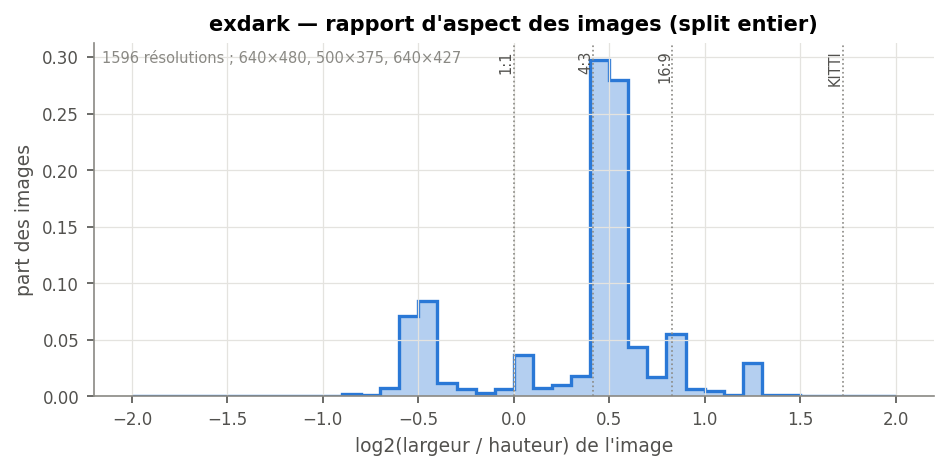

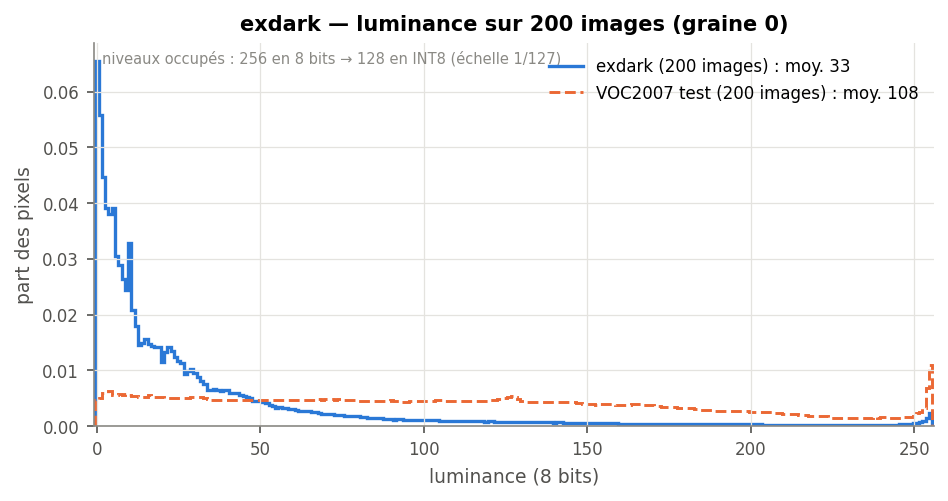

In [8]:
table(DS.md_images)
show("resolutions")
show("intensites")

## Ancres (T16.9)

Boîtes du groupe train en pixels d'entrée letterbox, ancres de la cfg, de VOC, de
COCO et du k-means (`tools/kmeans_anchors.py`, mêmes `--size` et `--seed`).

| ancres | w,h (px à 416×416) | IoU moyenne |
|---|---|---|
| VOC (tiny-yolov2-voc) | `35,38  109,141  212,364  301,164  532,337` | 0,5173 |
| VOC (tiny-yolov3-voc) | `10,14  23,27  37,58  81,82  135,169  344,319` | 0,6085 |
| COCO (tiny-yolov3-coco) | `10,14  23,27  37,58  81,82  135,169  344,319` | 0,6085 |
| cfg du jeu (tiny-yolov3-exdark) | `27,38  63,67  70,137  172,105  128,216  277,221` | 0,6149 |
| k-means k = 5 (graine 0) | `29,40  74,72  76,151  164,162  289,220` | 0,5920 |
| k-means k = 6 (graine 0) | `27,38  63,67  70,137  172,105  128,216  277,221` | 0,6149 |

10 381 boîtes non-difficult du groupe train, letterbox 416×416.

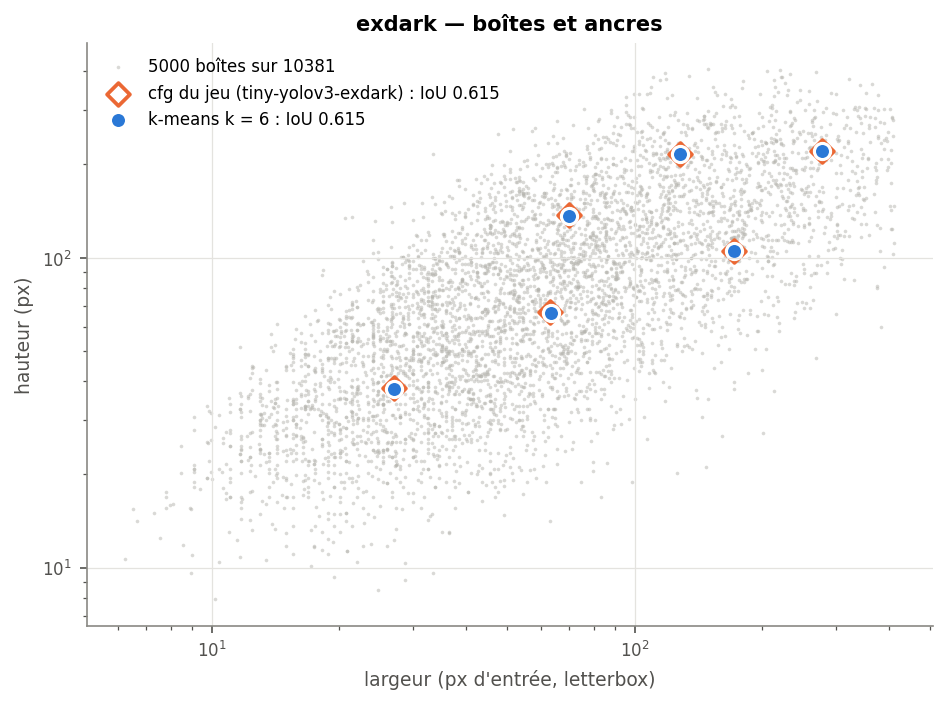

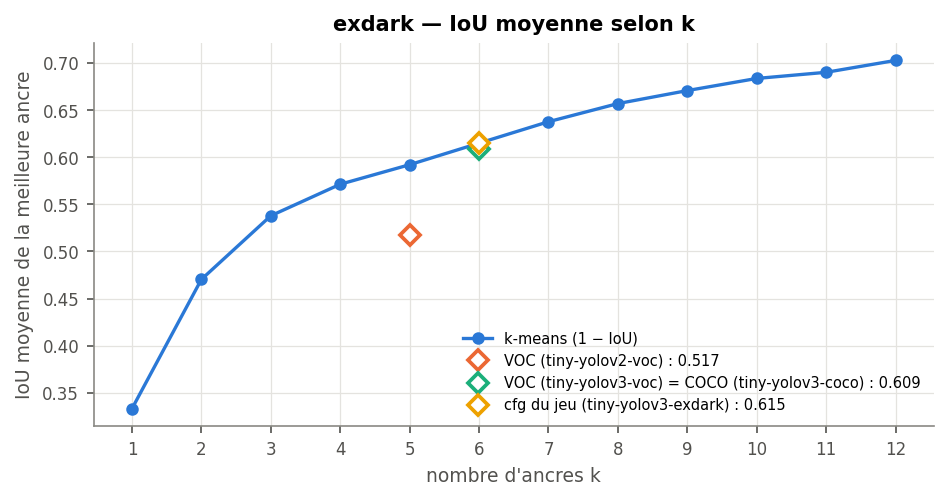

In [9]:
table(DS.md_ancres)
show("ancres")
show("ancres_k")

## Qualité des annotations (T16.10)

Boîtes retirées ou rognées par le chargeur, dégénérées, doublons, régions retirées ;
l'analyse signale, elle ne corrige pas (une correction passe par M11).

| partie | retirées (make_sample) | rognées | côté < 2 px (orig. / entrée) | doublons (IoU > 0,95) | régions retirées par le chargeur |
|---|---|---|---|---|---|
| train | 0 | 27 | 0 / 0 | 0 | — |
| test | 0 | 16 | 0 / 0 | 0 | — |
| ensemble | 0 | 43 | 0 / 0 | 0 | — |

2015_02622 : score 2 (retirées 0, rognées 2, dégénérées 0, doublons 0)
2015_06959 : score 2 (retirées 0, rognées 2, dégénérées 0, doublons 0)
2015_00115 : score 1 (retirées 0, rognées 1, dégénérées 0, doublons 0)
2015_00161 : score 1 (retirées 0, rognées 1, dégénérées 0, doublons 0)
2015_00167 : score 1 (retirées 0, rognées 1, dégénérées 0, doublons 0)
2015_00409 : score 1 (retirées 0, rognées 1, dégénérées 0, doublons 0)
2015_00437 : score 1 (retirées 0, rognées 1, dégénérées 0, doublons 0)
2015_00508 : score 1 (retirées 0, rognées 1, dégénérées 0, doublons 0)
2015_00759 : score 1 (retirées 0, rognées 1, dégénérées 0, doublons 0)
2015_00824 : score 1 (retirées 0, rognées 1, dégénérées 0, doublons 0)


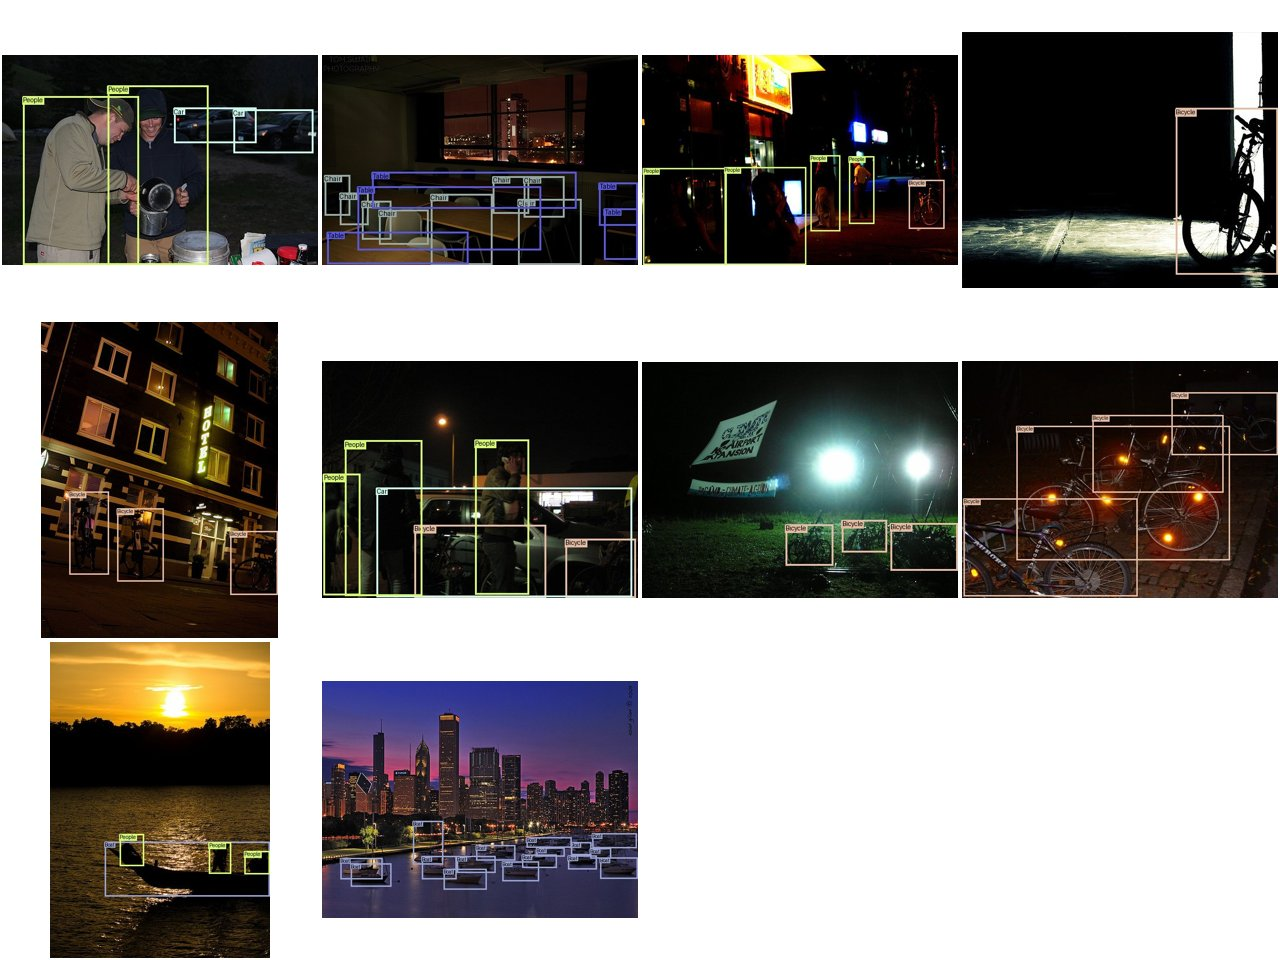

In [10]:
table(DS.md_qualite)
sus = DS.whole(STATS).get("qualite", {}).get("suspects", [])
for d in sus:
    print(f"{d['id']} : score {d['score']} (retirées {d['retirées']}, rognées "
          f"{d['rognées']}, dégénérées {d['dégénérées']}, doublons {d['doublons']})")
sheet = STATS.get("galerie", {}).get("planches", {}).get("suspectes")
if sheet:
    display(Img(filename=str(Path(OUT, sheet))))

## Écart entre splits et couverture hors domaine (T16.11)

Distance en variation totale entre train et test, par grandeur ; part des objets qui
ont une classe VOC ou COCO (ce qu'évaluent les notebooks hors domaine de T14.5).

| grandeur (train ↔ test) | variation totale |
|---|---|
| classes | 0,112 |
| area_in | 0,075 |
| w_in | 0,068 |
| h_in | 0,082 |
| aspect | 0,045 |
| per_image | 0,157 |

| split | classes du modèle | objets couverts | part | évalués (non-difficult) |
|---|---|---|---|---|
| train | VOC | 9 517 | 91,7 % | 9 517 |
| train | COCO | 10 381 | 100,0 % | 10 381 |
| test | VOC | 6 761 | 95,0 % | 6 761 |
| test | COCO | 7 117 | 100,0 % | 7 117 |

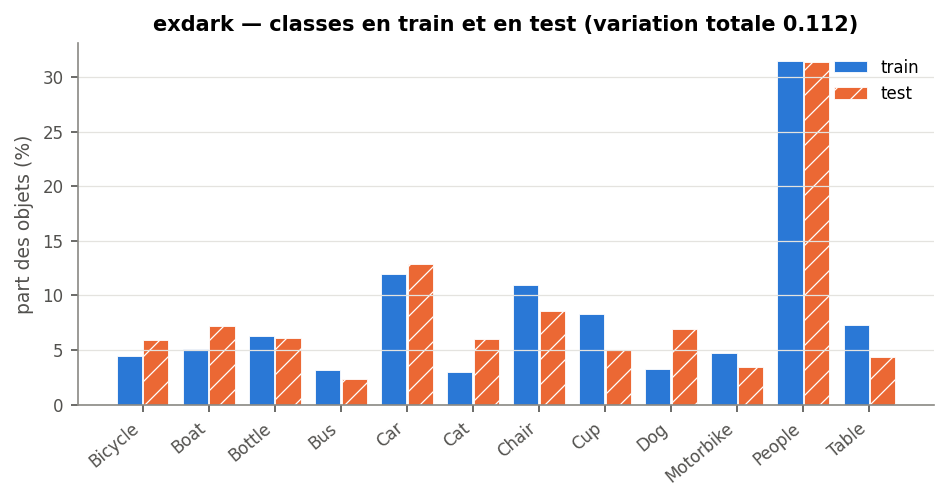

In [11]:
table(DS.md_ecart)
show("ecart")

## Question propre au jeu

Luminosité par type d'éclairage, et écart aux images de calibration VOC. (renvoi : T11.3)

| éclairage | images | luminance moy. |
|---|---|---|
| Low | 8 | 6.5 |
| Weak | 20 | 20.4 |
| Ambient | 63 | 25.5 |
| Single | 27 | 31.8 |
| Window | 7 | 35.4 |
| Strong | 45 | 38.4 |
| Object | 14 | 40.1 |
| Screen | 3 | 59.5 |
| Twilight | 13 | 77.9 |

VOC2007 test (200 images) : luminance moyenne 107.7


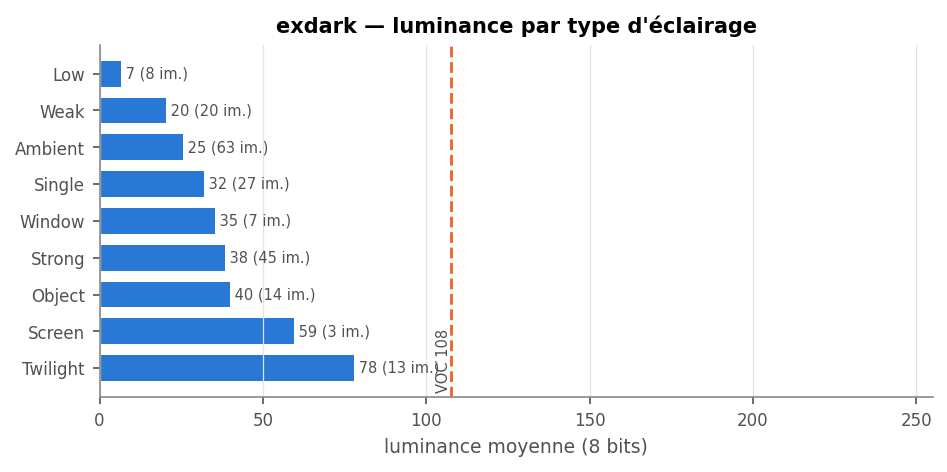

In [12]:
light = STATS.get("exdark_light")
if light:
    rows = ["| éclairage | images | luminance moy. |", "|---|---|---|"]
    rows += [f"| {k} | {v['images']} | {v['lum_mean']:.1f} |" for k, v in light.items()]
    display(Markdown("\n".join(rows)))
ref = STATS.get("voc_ref")
if ref:
    print(f"VOC2007 test ({ref['images']} images) : luminance moyenne {ref['lum_mean']:.1f}")
show("eclairage")

## Résumé

In [13]:
table(DS.md_synthese)
print(f"sorties : {OUT}/ (stats.json, stats.md, figures/, galerie/) ; "
      f"révision {TRACE['rev']}")
print("commandes équivalentes :")
for c in C.HISTORY:
    print("  " + c)

| partie | images | objets | difficult | images vides | objets/image (méd. / max) | petits < 32² à 416×416 | plus petits qu'une cellule | cibles perdues | images > 256 / > 1 024 |
|---|---|---|---|---|---|---|---|---|---|
| train | 3 000 | 10 381 | 0 | 1 | 2 / 33 | 17,8 % | 13x13 10,4 % · 26x26 0,6 % | 0,56 % | 0 / 0 |
| test | 2 563 | 7 117 | 0 | 0 | 2 / 30 | 18,5 % | 13x13 11,8 % · 26x26 1,7 % | 1,00 % | 0 / 0 |
| ensemble | 5 563 | 17 498 | 0 | 1 | 2 / 33 | 18,1 % | 13x13 11,0 % · 26x26 1,0 % | 0,74 % | 0 / 0 |

sorties : build/notebooks/exdark/stats/ (stats.json, stats.md, figures/, galerie/) ; révision 214f269
commandes équivalentes :
  python tools/data_stats.py --dataset exdark --size 416 --resize letterbox --net build/m11/cfg/tiny-yolov3-exdark.cfg --sample 200 --gallery 8 --seed 0 --figures --out build/notebooks/exdark/stats
